In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load data
df = pd.read_csv("../data/spotify_data_clean.csv")

In [2]:
# Feature Engineering
df["release_year"] = pd.to_datetime(df["album_release_date"]).dt.year
df["artist_followers_log"] = np.log1p(df["artist_followers"])
df["artist_impact"] = df["artist_followers_log"] * df["artist_popularity"]
df["explicit"] = df["explicit"].astype(str)

# Handle missing values
df = df.dropna(subset=["track_popularity"])

# Define target and features for modeling
y = df["track_popularity"]
X = df.drop(columns=["track_popularity", "track_id", "track_name", "album_id", "album_name", "artist_name", "artist_genres", "album_release_date", "album_type"])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define numeric and categorical features
numeric_features = [
    "artist_popularity", "artist_followers", "track_duration_min",
    "album_total_tracks", "release_year", "artist_followers_log", "artist_impact"
]
categorical_features = ["explicit"]

# Preprocessing pipelines
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Linear
Best Params: {}
Test RMSE: 20.73188733384889
Test R2: 0.27684215848934135

Ridge
Best Params: {'model__alpha': 1.0}
Test RMSE: 20.731863801333038
Test R2: 0.2768438001839383

RandomForest
Best Params: {'model__max_depth': 15, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 600}
Test RMSE: 18.84867610926293
Test R2: 0.4022533881243612

GradientBoosting
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__max_iter': 100}
Test RMSE: 19.192344545793077
Test R2: 0.3802572100161733


/Users/dallinrobinson/School/2026_Winter/STAT_486/STAT486-Final-Project/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



SVR
Best Params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Test RMSE: 20.792456493032542
Test R2: 0.2726105084599122


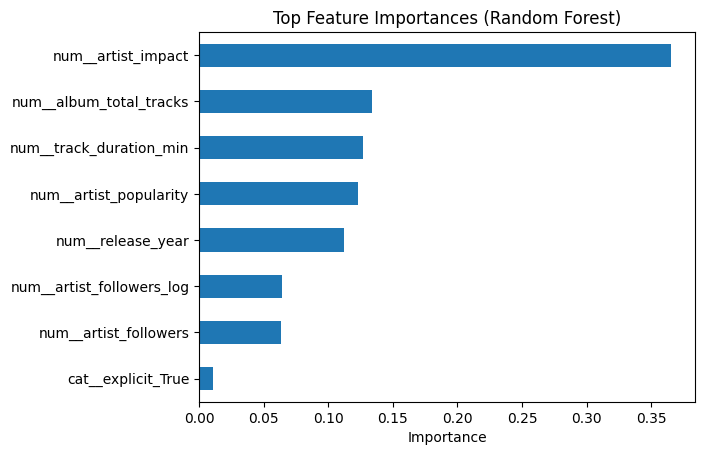

In [4]:
# Define models for comparison
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": HistGradientBoostingRegressor(),
    "SVR": SVR()
}

param_grids = {
    "Linear": {},
    "Ridge": {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    "RandomForest": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [10, 15, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "GradientBoosting": {
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__max_iter": [100, 200]
    },
    "SVR": {
        "model__C": [0.1, 1, 10, 50],
        "model__kernel": ["rbf"],
        "model__gamma": ["scale", "auto"]
    }
}

# Train models and evaluate performance
results = []
trained_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    trained_models[name] = best_model  # SAVE TRAINED PIPELINE

    preds = best_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "model": name,
        "rmse": rmse,
        "r2": r2,
        "best_params": grid.best_params_
    })

    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Test RMSE:", rmse)
    print("Test R2:", r2)

# Feature Importance from Random Forest (Best Model)
best_rf_model = trained_models["RandomForest"]  # FIXED

feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf_model.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(10).plot(kind="barh")
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

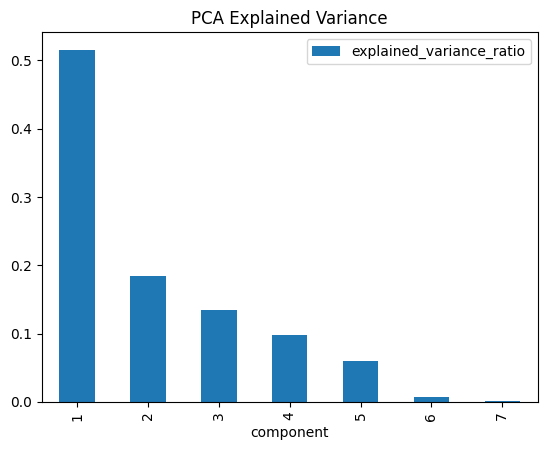

         artist_popularity  artist_followers  track_duration_min  \
cluster                                                            
0                44.005672      1.814527e+05            2.968739   
1                92.918265      1.084231e+08            3.941751   
2                75.850128      1.489899e+07            3.623009   

         album_total_tracks  release_year  artist_followers_log  \
cluster                                                           
0                 10.988656   2018.544939             10.380658   
1                 18.160967   2017.405338             18.458586   
2                 14.020821   2012.941662             15.882525   

         artist_impact  track_popularity  
cluster                                   
0           490.359842         36.139616  
1          1716.343907         62.950792  
2          1213.665112         57.161854  


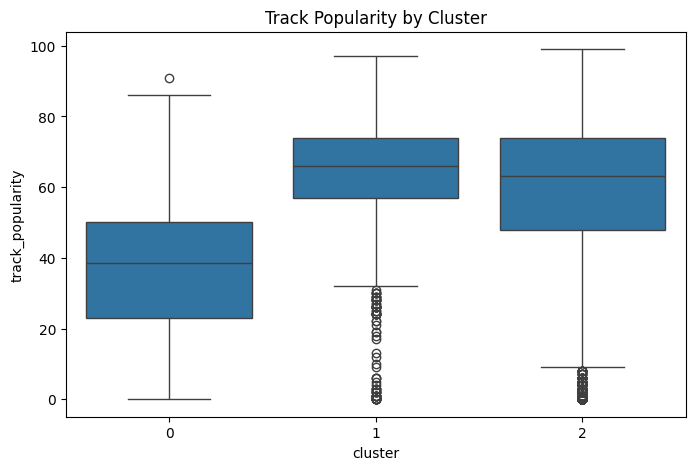

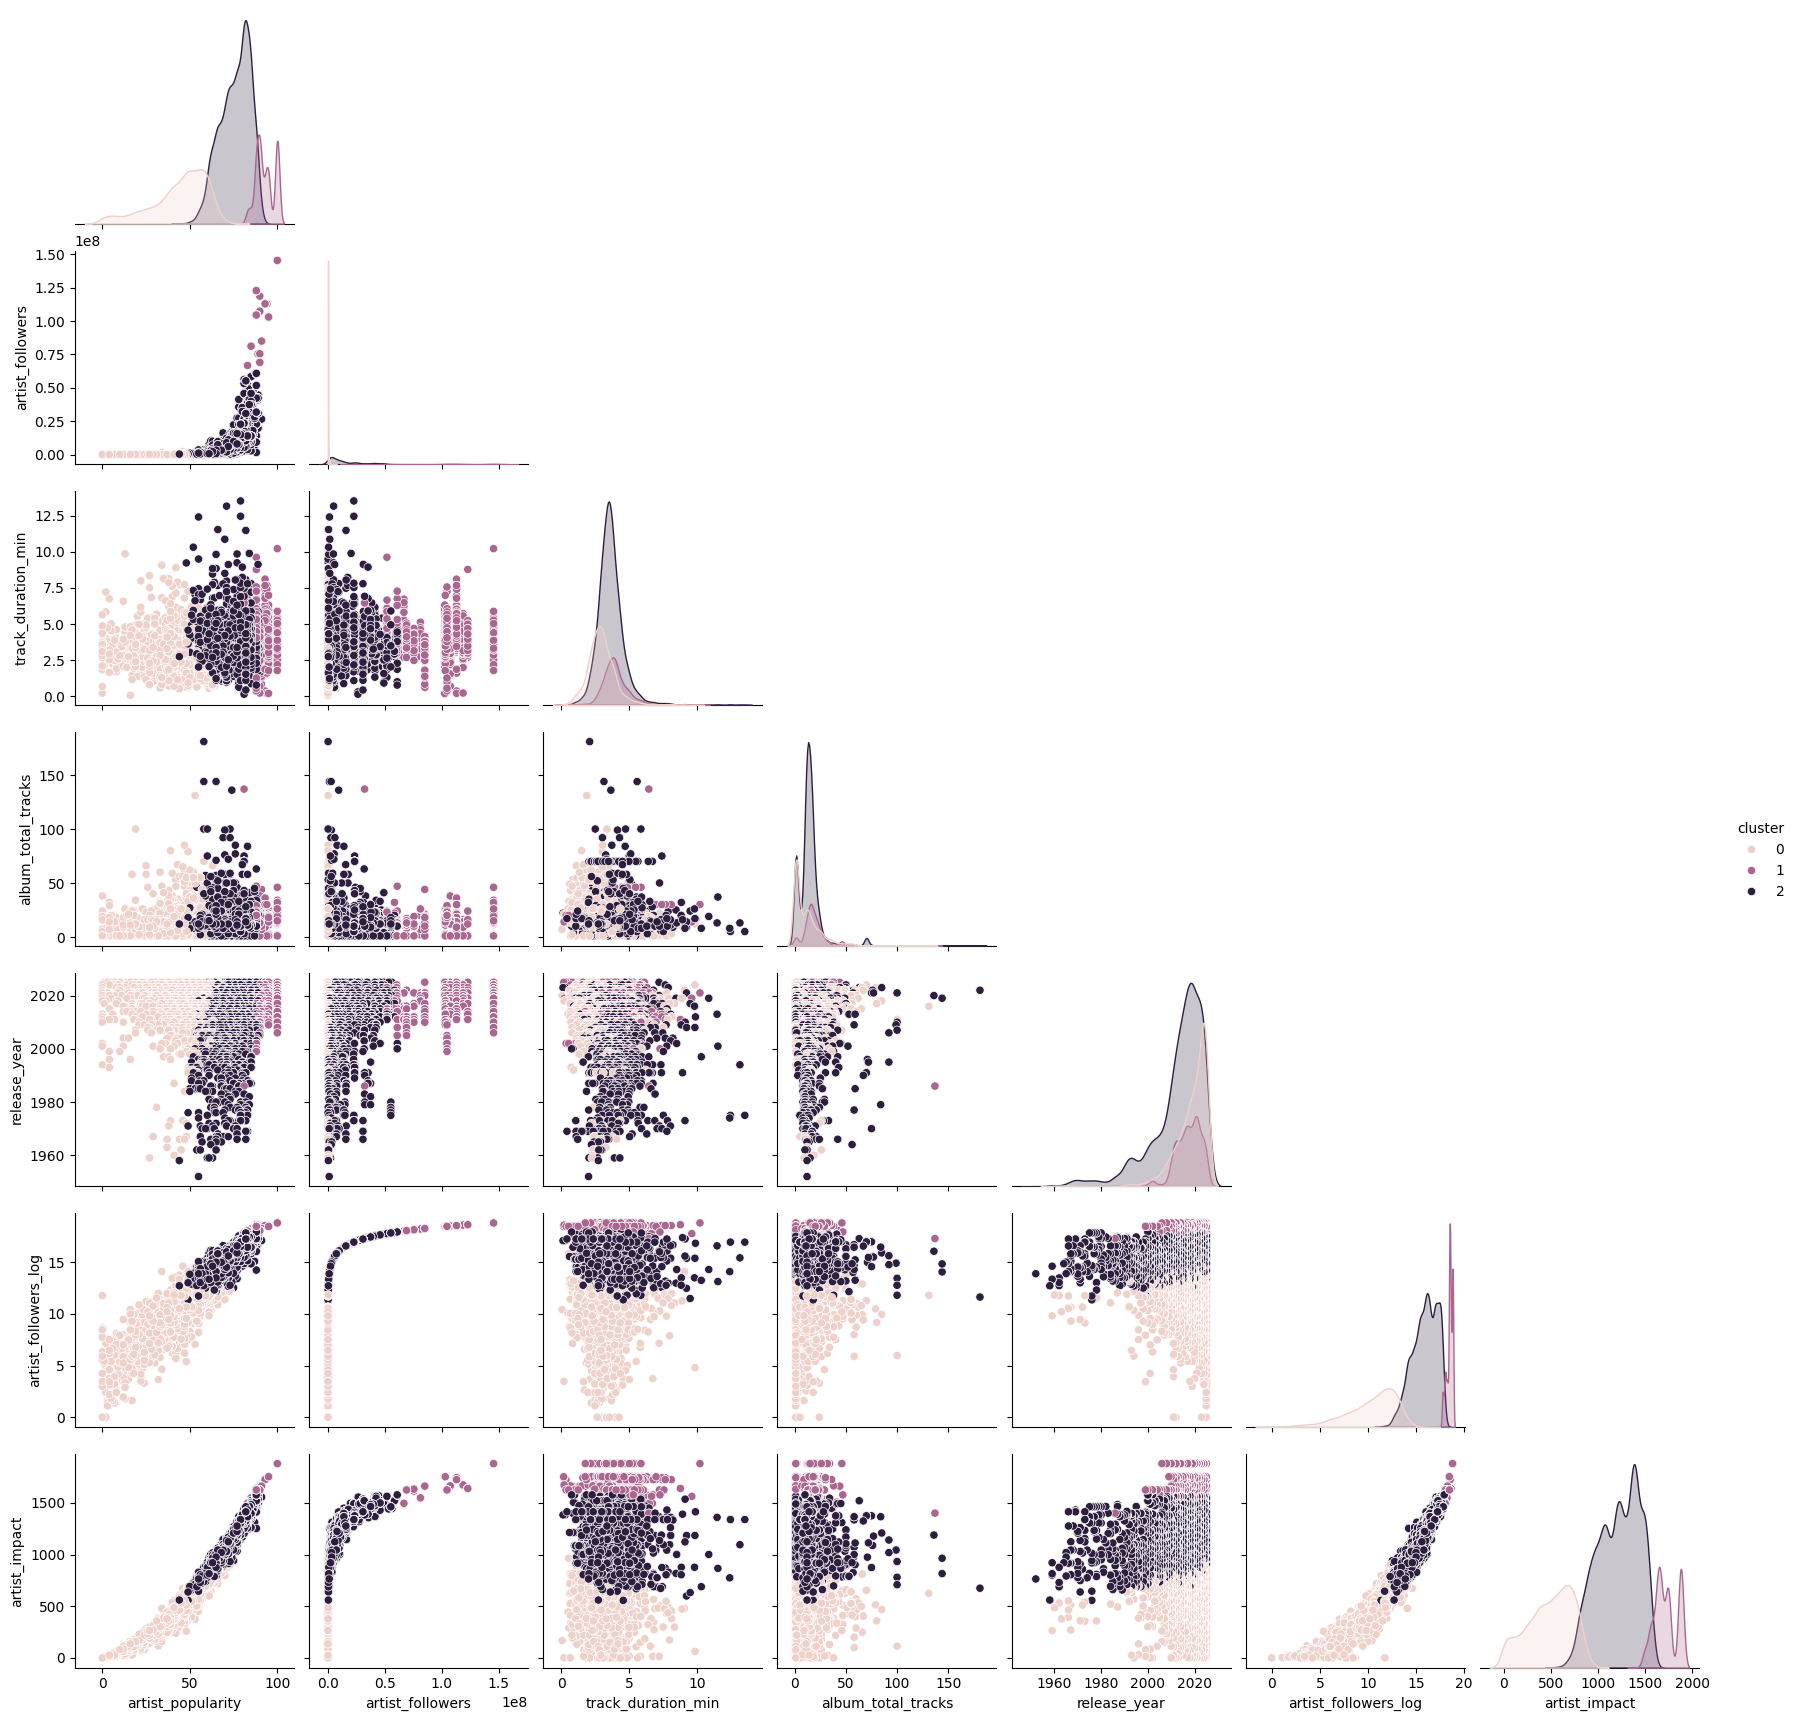

In [5]:
# PCA for Dimensionality Reduction (Feature Selection)
X_scaled = StandardScaler().fit_transform(df[numeric_features])
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pd.DataFrame({
    "component": np.arange(1, len(numeric_features) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})
explained_variance.plot(x="component", y="explained_variance_ratio", kind="bar", title="PCA Explained Variance")
plt.show()

# Clustering with KMeans (Optimal k = 3 from silhouette analysis)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Cluster analysis
cluster_summary = df.groupby("cluster")[numeric_features + ["track_popularity"]].mean()
print(cluster_summary)

# Visualize clustering with track popularity
plt.figure(figsize=(8,5))
sns.boxplot(x="cluster", y="track_popularity", data=df)
plt.title("Track Popularity by Cluster")
plt.show()

# Pairplot for clusters
sns.pairplot(df, vars=numeric_features, hue="cluster", corner=True)
plt.show()